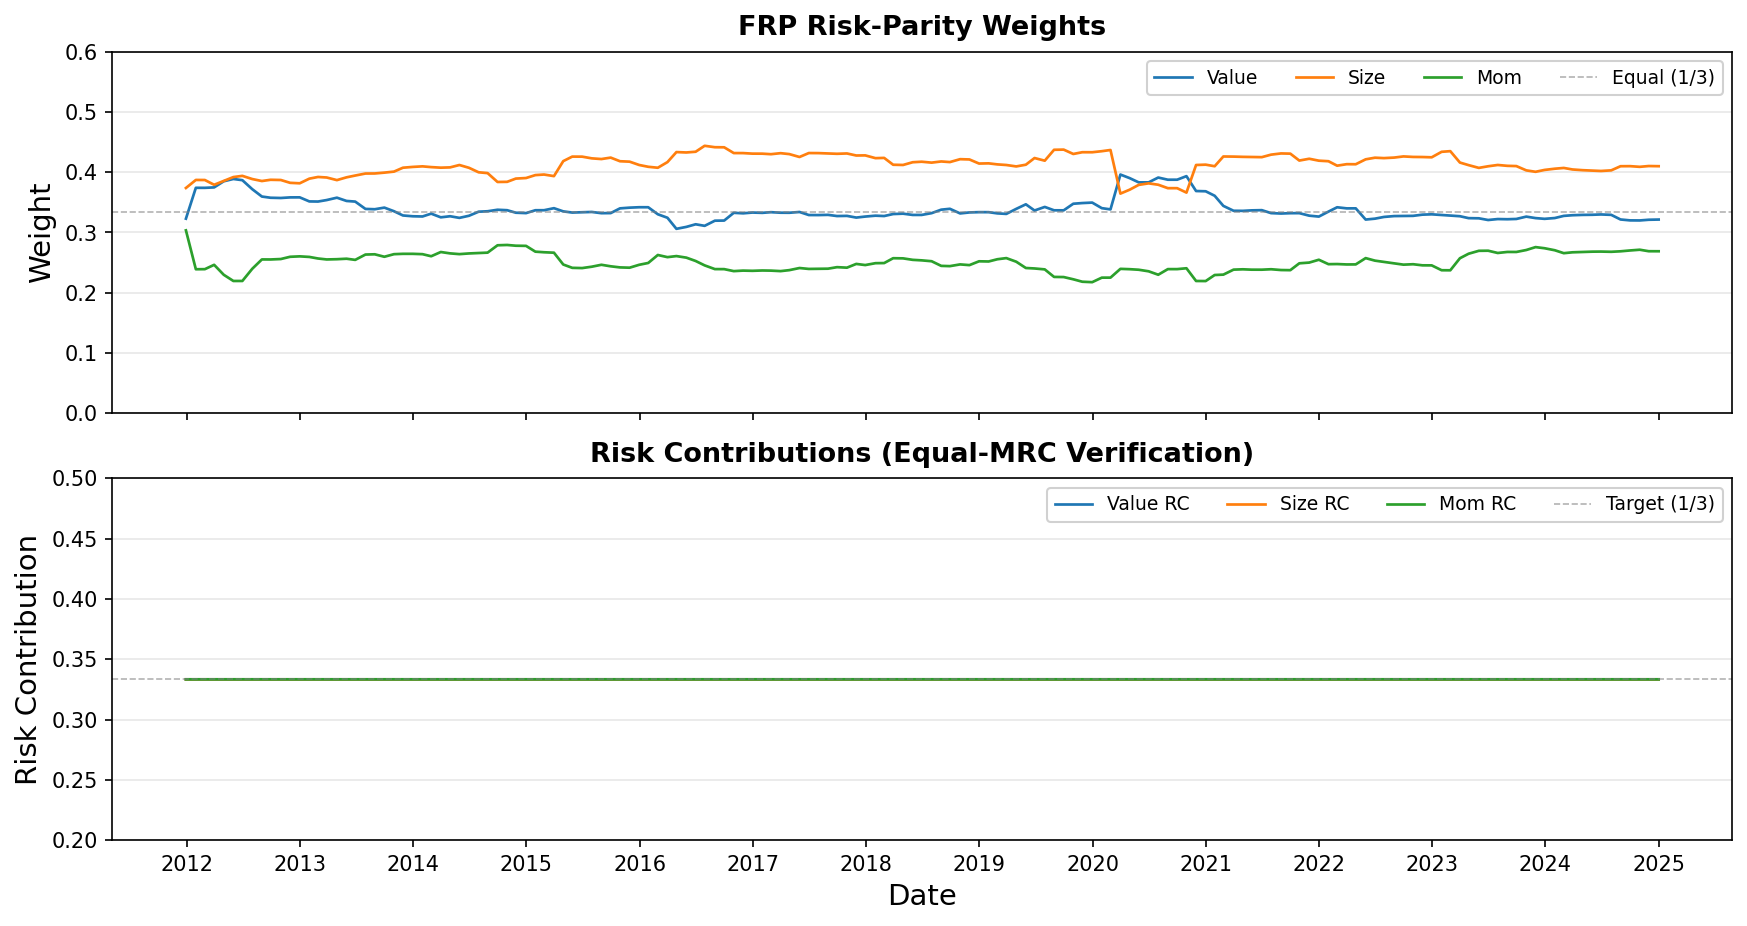

✓ 图表已保存至 figures/frp_weights_and_risk_contributions.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── 读取数据 ──────────────────────────────────────────────────
frp = pd.read_csv("data/sp500_frp_weights.csv.gz")
frp["date"] = pd.to_datetime(frp["date"])

# ── 创建上下双面板图表（比例接近 720:380）───────────────────────
target_ratio = 720 / 380
fig_width = 12
fig_height = fig_width / target_ratio
axis_label_fs = 14
title_fs = 13

fig, axes = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    dpi=150,
    sharex=True
)
fig.subplots_adjust(left=0.08, right=0.98, top=0.94, bottom=0.11, hspace=0.18)

colors = {"value": "#1f77b4", "size": "#ff7f0e", "mom": "#2ca02c"}

# ── 上图：FRP 权重 ───────────────────────────────────────────
ax1 = axes[0]
ax1.plot(frp["date"], frp["w_value"], label="Value", color=colors["value"], lw=1.3)
ax1.plot(frp["date"], frp["w_size"],  label="Size",  color=colors["size"],  lw=1.3)
ax1.plot(frp["date"], frp["w_mom"],   label="Mom",   color=colors["mom"],   lw=1.3)
ax1.axhline(1/3, ls="--", color="grey", lw=0.8, alpha=0.6, label="Equal (1/3)")
ax1.set_ylabel("Weight", fontsize=axis_label_fs)
ax1.set_title("FRP Risk-Parity Weights", fontsize=title_fs, fontweight="bold", pad=8)
ax1.legend(loc="upper right", fontsize=9, ncol=4, framealpha=0.9)
ax1.set_ylim(0, 0.6)
ax1.grid(axis="y", alpha=0.3)

# ── 下图：风险贡献 ───────────────────────────────────────────
ax2 = axes[1]
ax2.plot(frp["date"], frp["rc_value"], label="Value RC", color=colors["value"], lw=1.3)
ax2.plot(frp["date"], frp["rc_size"],  label="Size RC",  color=colors["size"],  lw=1.3)
ax2.plot(frp["date"], frp["rc_mom"],   label="Mom RC",   color=colors["mom"],   lw=1.3)
ax2.axhline(1/3, ls="--", color="grey", lw=0.8, alpha=0.6, label="Target (1/3)")
ax2.set_ylabel("Risk Contribution", fontsize=axis_label_fs)
ax2.set_xlabel("Date", fontsize=axis_label_fs)
ax2.set_title("Risk Contributions (Equal-MRC Verification)", fontsize=title_fs, fontweight="bold", pad=8)
ax2.legend(loc="upper right", fontsize=9, ncol=4, framealpha=0.9)
ax2.set_ylim(0.2, 0.5)
ax2.grid(axis="y", alpha=0.3)

# ── 共享 X 轴格式 ────────────────────────────────────────────
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.savefig("figures/frp_weights_and_risk_contributions.png", dpi=320, bbox_inches="tight")
plt.show()
print("✓ 图表已保存至 figures/frp_weights_and_risk_contributions.png")